In [ ]:
import zipfile
import os

zip_path = "/content/daily+and+sports+activities.zip"   # change if your zip name differs
extract_path = "/content/DASD"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Complete!")

print(os.listdir(extract_path))

Extraction Complete!
['data']


In [ ]:
import os
import numpy as np

dataset_path = "/content/DASD/data"

activities = sorted(os.listdir(dataset_path))

print("Activities:", activities)

sample_activity = activities[0]

participants = sorted(
    os.listdir(
        os.path.join(dataset_path, sample_activity)
    )
)

print("Participants:", participants)

sample_participant = participants[0]

files = sorted(
    os.listdir(
        os.path.join(
            dataset_path,
            sample_activity,
            sample_participant
        )
    )
)

print("Files:", files)

sample_file = os.path.join(
    dataset_path,
    sample_activity,
    sample_participant,
    files[0]
)

signal = np.loadtxt(
    sample_file,
    delimiter=','
)

print("\nSample File:", sample_file)
print("Shape:", signal.shape)
print("\nFirst 5 rows:")
print(signal[:5])

Activities: ['a01', 'a02', 'a03', 'a04', 'a05', 'a06', 'a07', 'a08', 'a09', 'a10', 'a11', 'a12', 'a13', 'a14', 'a15', 'a16', 'a17', 'a18', 'a19']
Participants: ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'p7', 'p8']
Files: ['s01.txt', 's02.txt', 's03.txt', 's04.txt', 's05.txt', 's06.txt', 's07.txt', 's08.txt', 's09.txt', 's10.txt', 's11.txt', 's12.txt', 's13.txt', 's14.txt', 's15.txt', 's16.txt', 's17.txt', 's18.txt', 's19.txt', 's20.txt', 's21.txt', 's22.txt', 's23.txt', 's24.txt', 's25.txt', 's26.txt', 's27.txt', 's28.txt', 's29.txt', 's30.txt', 's31.txt', 's32.txt', 's33.txt', 's34.txt', 's35.txt', 's36.txt', 's37.txt', 's38.txt', 's39.txt', 's40.txt', 's41.txt', 's42.txt', 's43.txt', 's44.txt', 's45.txt', 's46.txt', 's47.txt', 's48.txt', 's49.txt', 's50.txt', 's51.txt', 's52.txt', 's53.txt', 's54.txt', 's55.txt', 's56.txt', 's57.txt', 's58.txt', 's59.txt', 's60.txt']

Sample File: /content/DASD/data/a01/p1/s01.txt
Shape: (125, 45)

First 5 rows:
[[ 8.1305e+00  1.0349e+00  5.4217e+00 -9.46

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler(
    feature_range=(-1, 1)
)

normalized_sample = scaler.fit_transform(signal)

print("Normalized Shape:", normalized_sample.shape)

print("Minimum Value:", normalized_sample.min())
print("Maximum Value:", normalized_sample.max())

print("\nFirst 5 rows:")
print(normalized_sample[:5])

Normalized Shape: (125, 45)
Minimum Value: -1.0
Maximum Value: 1.0000000000000009

First 5 rows:
[[ 0.87452949 -0.59668389 -0.75754772 -0.29393175 -0.44106784  0.17883023
   0.64292683 -0.46659289  0.925       0.32907752 -0.30906213  0.75530587
  -0.31956858 -0.24558315  0.31479582 -0.04089332  0.17361111  0.07709899
   0.37802098  0.48363252  0.07271306  0.2251917  -0.128398   -0.19959974
   0.10126582 -0.04785276  0.33009248  0.34772897 -0.30769231  0.12995193
   0.3378875  -0.03949166 -0.45984621 -0.14611872 -0.91099476 -0.07213851
   0.00750626 -0.08100147  0.03350254  0.2064236  -0.63970123 -0.03285374
   0.09053498 -0.54545455 -0.29359514]
 [ 0.87452949 -0.75495263 -0.84407172 -0.2917384  -0.29502808  0.41075742
   0.63317073 -0.08507401  0.98951613  0.52829538 -0.96121884  0.63046192
   0.01930837 -0.2472831   0.24410256 -0.04723102  0.34567901  0.04148971
   0.5120839   0.17529039 -0.06802189 -0.04932399  0.10110905  0.20077031
  -0.18987342  0.20736196  0.64216267  0.01116902 

In [ ]:
pip install pyts

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 42.5 MB/s eta 0:00:00


In [ ]:
from pyts.image import MarkovTransitionField
import numpy as np

mtf = MarkovTransitionField(
    n_bins=8,
    strategy='quantile'
)

mtf_images = []

for ch in range(normalized_sample.shape[1]):

    signal = normalized_sample[:, ch]

    signal = signal.reshape(1, -1)

    mtf_image = mtf.fit_transform(
        signal
    )[0]

    mtf_images.append(
        mtf_image
    )

mtf_tensor = np.stack(
    mtf_images,
    axis=-1
)

print("MTF Tensor Shape:", mtf_tensor.shape)

/usr/local/lib/python3.12/dist-packages/pyts/preprocessing/discretizer.py:168: UserWarning: Some quantiles are equal. The number of bins will be smaller for sample [0]. Consider decreasing the number of bins or removing these samples.
  warn("Some quantiles are equal. The number of bins will "


MTF Tensor Shape: (125, 125, 45)


In [ ]:
from scipy.ndimage import zoom
import numpy as np

mtf_resized_channels = []

for ch in range(mtf_tensor.shape[-1]):

    img = mtf_tensor[:, :, ch]

    img_resized = zoom(
        img,
        (128 / img.shape[0],
         128 / img.shape[1]),
        order=1
    )

    mtf_resized_channels.append(
        img_resized
    )

mtf128_tensor = np.stack(
    mtf_resized_channels,
    axis=-1
)

print("Resized Shape:", mtf128_tensor.shape)

Resized Shape: (128, 128, 45)


In [ ]:
import os
import numpy as np
from pyts.image import MarkovTransitionField
from sklearn.preprocessing import MinMaxScaler
from scipy.ndimage import zoom
import warnings

warnings.filterwarnings("ignore")

# Paths
dataset_path = "/content/DASD/data"
save_path = "/content/MTF128_DATA"

os.makedirs(save_path, exist_ok=True)

# MTF Transformer
mtf = MarkovTransitionField(
    image_size=125,
    n_bins=5,
    strategy='quantile'
)

sample_count = 0

activities = sorted(os.listdir(dataset_path))

for activity in activities:

    activity_path = os.path.join(
        dataset_path,
        activity
    )

    if not os.path.isdir(activity_path):
        continue

    participants = sorted(
        os.listdir(activity_path)
    )

    for participant in participants:

        participant_path = os.path.join(
            activity_path,
            participant
        )

        if not os.path.isdir(participant_path):
            continue

        files = sorted(
            os.listdir(participant_path)
        )

        for file in files:

            # DASD files are .txt
            if not file.endswith(".txt"):
                continue

            file_path = os.path.join(
                participant_path,
                file
            )

            try:

                signal_data = np.loadtxt(
                    file_path,
                    delimiter=','
                )

                # remove NaN/Inf
                signal_data = np.nan_to_num(
                    signal_data,
                    nan=0.0,
                    posinf=0.0,
                    neginf=0.0
                )

                # normalize to [-1,1]
                scaler = MinMaxScaler(
                    feature_range=(-1, 1)
                )

                normalized_signal = scaler.fit_transform(
                    signal_data
                )

                mtf_channels = []

                for ch in range(
                    normalized_signal.shape[1]
                ):

                    signal = normalized_signal[:, ch]

                    signal = signal.reshape(
                        1, -1
                    )

                    # generate MTF
                    mtf_image = mtf.fit_transform(
                        signal
                    )[0]

                    # resize 125 -> 128
                    mtf_image = zoom(
                        mtf_image,
                        (128 / 125, 128 / 125),
                        order=1
                    )

                    mtf_channels.append(
                        mtf_image
                    )

                mtf_tensor = np.stack(
                    mtf_channels,
                    axis=-1
                )

                save_name = (
                    f"{activity}_{participant}_{file[:-4]}.npy"
                )

                np.save(
                    os.path.join(
                        save_path,
                        save_name
                    ),
                    mtf_tensor.astype(
                        np.float32
                    )
                )

                sample_count += 1

            except Exception as e:

                print(
                    f"Error in {file_path}"
                )

                print(e)

    print(f"Finished {activity}")

print("\nTotal Samples Saved:", sample_count)

Finished a01
Finished a02
Finished a03
Finished a04
Finished a05
Finished a06
Finished a07
Finished a08
Finished a09
Finished a10
Finished a11
Finished a12
Finished a13
Finished a14
Finished a15
Finished a16
Finished a17
Finished a18
Finished a19

Total Samples Saved: 9120


In [ ]:
import os

data_path = "/content/MTF128_DATA"

all_files = sorted(os.listdir(data_path))

file_paths = []
labels = []

for file in all_files:

    file_path = os.path.join(data_path, file)

    activity = file.split("_")[0]

    label = int(activity[1:]) - 1

    file_paths.append(file_path)
    labels.append(label)

print("Total Files:", len(file_paths))
print("Example:", file_paths[0])
print("Label:", labels[0])

Total Files: 9120
Example: /content/MTF128_DATA/a01_p1_s01.npy
Label: 0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    file_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 7296
Testing Samples : 1824


In [ ]:
import torch
from torch.utils.data import Dataset
import numpy as np

class MTFDeepViTDataset(Dataset):

    def __init__(self, file_paths, labels):

        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):

        return len(self.file_paths)

    def __getitem__(self, idx):

        x = np.load(self.file_paths[idx])

        # (128,128,45) -> (45,128,128)
        x = np.transpose(
            x,
            (2, 0, 1)
        )

        x = torch.tensor(
            x,
            dtype=torch.float32
        )

        y = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return x, y

In [ ]:
train_dataset = MTFDeepViTDataset(
    X_train,
    y_train
)

test_dataset = MTFDeepViTDataset(
    X_test,
    y_test
)

print(
    "Train dataset size:",
    len(train_dataset)
)

print(
    "Test dataset size:",
    len(test_dataset)
)

Train dataset size: 7296
Test dataset size: 1824


In [ ]:
from torch.utils.data import DataLoader

batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
batch_x, batch_y = next(iter(train_loader))

print("Batch Shape:", batch_x.shape)
print("Labels Shape:", batch_y.shape)

Batch Shape: torch.Size([8, 45, 128, 128])
Labels Shape: torch.Size([8])


In [ ]:
import torch
import torch.nn as nn
from einops import rearrange


# ---------------- Transformer Block ---------------- #

class TransformerBlock(nn.Module):

    def __init__(
        self,
        dim,
        heads,
        mlp_dim,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):

        attn_out, _ = self.attn(
            self.norm1(x),
            self.norm1(x),
            self.norm1(x)
        )

        x = x + attn_out

        x = x + self.mlp(
            self.norm2(x)
        )

        return x


# ---------------- DeepViT ---------------- #

class DeepViT19Class(nn.Module):

    def __init__(
        self,
        image_size=128,
        patch_size=16,
        in_channels=45,
        num_classes=19,
        embed_dim=768,
        depth=24,
        num_heads=12,
        mlp_dim=3072,
        dropout=0.1
    ):

        super().__init__()

        assert image_size % patch_size == 0

        self.patch_size = patch_size

        num_patches = (
            image_size // patch_size
        ) ** 2

        patch_dim = (
            in_channels *
            patch_size *
            patch_size
        )

        self.patch_embedding = nn.Linear(
            patch_dim,
            embed_dim
        )

        self.cls_token = nn.Parameter(
            torch.randn(
                1,
                1,
                embed_dim
            )
        )

        self.pos_embedding = nn.Parameter(
            torch.randn(
                1,
                num_patches + 1,
                embed_dim
            )
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.transformer = nn.ModuleList(
            [
                TransformerBlock(
                    dim=embed_dim,
                    heads=num_heads,
                    mlp_dim=mlp_dim,
                    dropout=dropout
                )
                for _ in range(depth)
            ]
        )

        self.norm = nn.LayerNorm(
            embed_dim
        )

        self.head = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x):

        x = rearrange(
            x,
            'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
            p1=self.patch_size,
            p2=self.patch_size
        )

        x = self.patch_embedding(x)

        b, n, _ = x.shape

        cls_tokens = self.cls_token.expand(
            b,
            -1,
            -1
        )

        x = torch.cat(
            (cls_tokens, x),
            dim=1
        )

        x = x + self.pos_embedding[:, :(n + 1)]

        x = self.dropout(x)

        for block in self.transformer:

            x = block(x)

        x = self.norm(x)

        cls_output = x[:, 0]

        return self.head(cls_output)

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = DeepViT19Class(
    image_size=128,
    patch_size=16,
    in_channels=45,
    num_classes=19
).to(device)

print("DeepViT model created!")

DeepViT model created!


In [ ]:
x = torch.randn(
    2,
    45,
    128,
    128
).to(device)

out = model(x)

print("Output Shape:", out.shape)

Output Shape: torch.Size([2, 19])


In [ ]:
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

criterion = nn.CrossEntropyLoss()

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0.05
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=15
)

In [ ]:
batch_x, batch_y = next(iter(train_loader))

batch_x = batch_x.to(device)

with torch.no_grad():
    out = model(batch_x)

print(out.shape)

torch.Size([8, 19])


In [ ]:
from tqdm import tqdm
import torch

num_epochs = 15

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader)

    for images, labels in pbar:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

        accuracy = 100.0 * correct / total

        pbar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{accuracy:.2f}"
        )

    scheduler.step()

    epoch_loss = running_loss / len(train_loader)

    epoch_acc = 100.0 * correct / total

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {epoch_loss:.4f}")
    print(f"Train Accuracy: {epoch_acc:.2f}%")

100%|██████████| 912/912 [04:22<00:00,  3.47it/s, accuracy=14.99, loss=1.1892]



Epoch 1/15
Train Loss: 2.5781
Train Accuracy: 14.99%


100%|██████████| 912/912 [04:22<00:00,  3.47it/s, accuracy=49.42, loss=0.8295]



Epoch 2/15
Train Loss: 1.2096
Train Accuracy: 49.42%


100%|██████████| 912/912 [04:21<00:00,  3.48it/s, accuracy=62.49, loss=0.8371]


...


Epoch 13/15
Train Loss: 0.0616
Train Accuracy: 97.88%


100%|██████████| 912/912 [04:22<00:00,  3.47it/s, accuracy=98.51, loss=0.0096]



Epoch 14/15
Train Loss: 0.0487
Train Accuracy: 98.51%


100%|██████████| 912/912 [04:22<00:00,  3.48it/s, accuracy=98.74, loss=0.0785]


Epoch 15/15
Train Loss: 0.0423
Train Accuracy: 98.74%


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

acc = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9172149122807017
Precision: 0.918070919524505
Recall   : 0.9172149122807017
F1 Score : 0.9170545215231389


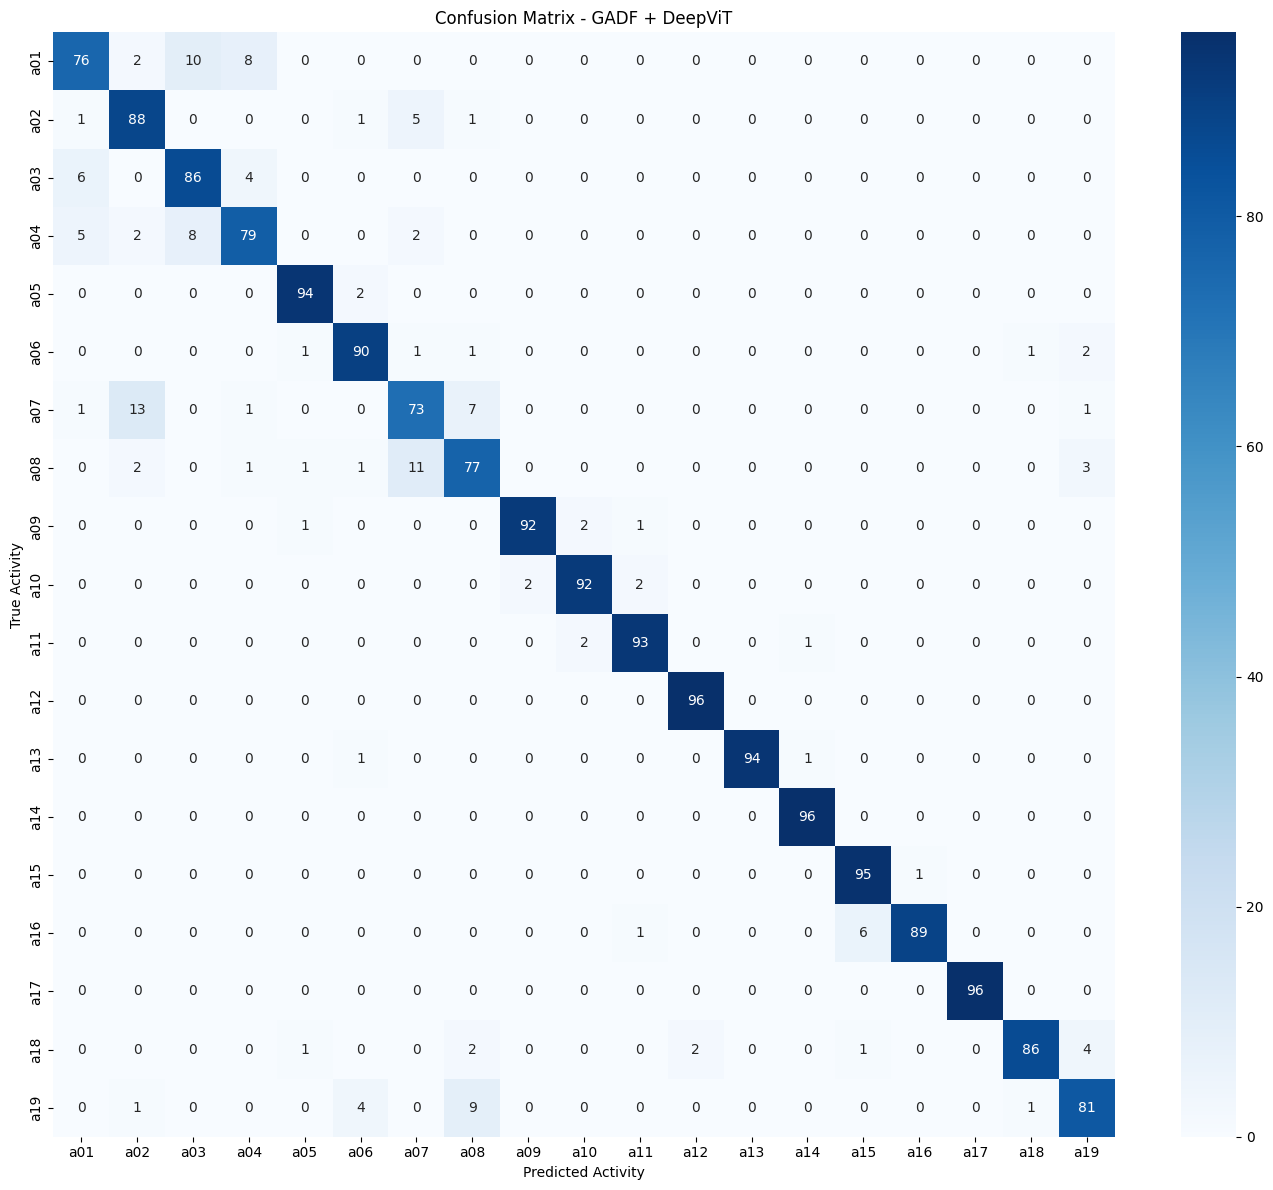

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cm = confusion_matrix(y_true, y_pred, labels=range(len(classes)))

classes = [f"a{i:02d}" for i in range(1, 20)]

cm_df = pd.DataFrame(
    cm,
    index=classes,
    columns=classes
)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm_df,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - GADF + DeepViT")
plt.xlabel("Predicted Activity")
plt.ylabel("True Activity")

plt.tight_layout()
plt.show()